# Tutorial about fluopy - homo-FRET simulation

Here we outline a simulation procedure for a homo-FRET pair that consist of two Cy5 fluorophores.

In [1]:
from pprint import pprint

%matplotlib inline

import numpy as np

import fluopy
import fluopy.analysis as an
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.miscellaneous as mi
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

In [2]:
fluopy.__version__

'not-installed'

In [3]:
rng = np.random.default_rng(seed=1)

## Define the fluorophore system

In [4]:
fluorophore_1 = fl.Fluorophore(name="cy5_dna", position=[0, 0])
fluorophore_2 = fl.Fluorophore(name="cy5_dna", position=[0, 4])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore_1, fluorophore_2])

In [5]:
pprint(vars(fluorophore_system))

{'count': 2,
 'distances': {(0, 1): np.float64(4.0), (1, 0): np.float64(4.0)},
 'fluorophores': [Fluorophore(identity=0,
                              name='cy5_dna',
                              position=array([0, 0]),
                              constants=Cy5_DNA(data_files='cy5_data',
                                                QUANTUM_YIELD=0.27,
                                                FLUORESCENCE_LIFETIME=1.7e-09,
                                                S1_QUENCH_RATE=0,
                                                ISC_ST_RATE=830000.0,
                                                ISC_TS_RATE=5000.0,
                                                RISC_RATE=0,
                                                STA_EFFICIENCY=0,
                                                PHOTOBLEACH_T1_RATE=10.0,
                                                PHOTOBLEACH_T2_RATE=0,
                                                DSTORM_PET_T_RATE_MOL=100000000.0,
  

## Define the transition set

In [6]:
transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2,
    wavelength=640,
    bleaching=False,
    energy_transfer=True,
    dstorm=False,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

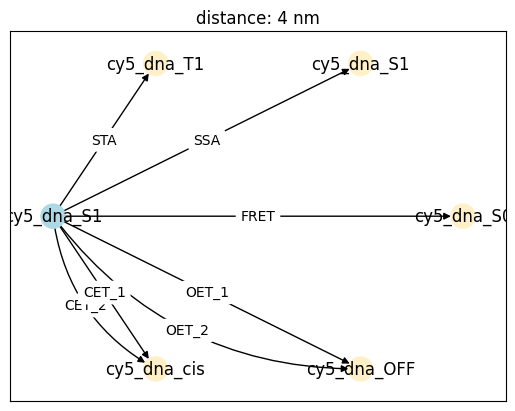

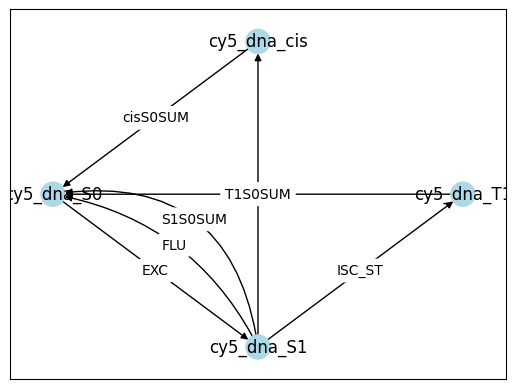

In [7]:
transition_set.plot(graph_type="shell", colors=None, scale=1);

In [8]:
transition_set.transition_df

transition_type  \
Fluorophore                       identity                                           
cy5_dna                           0                      TransitionType.EXCITATION   
                                  1            TransitionType.FLUORESCENT_EMISSION   
                                  2         TransitionType.INTERSYSTEM_CROSSING_ST   
                                  3                   TransitionType.ISOMERIZATION   
                                  4               TransitionType.S1_S0_TRANSITIONS   
                                  5               TransitionType.T1_S0_TRANSITIONS   
                                  6              TransitionType.CIS_S0_TRANSITIONS   
D: cy5_dna, A: cy5_dna, dist: 4.0 7                      TransitionType.CIS_FRET_1   
                                  8                      TransitionType.CIS_FRET_2   
                                  9                      TransitionType.OFF_FRET_1   
                                  10                     TransitionType.OFF_FRET_2   
                                  11                           TransitionType.FRET   
                                  12               TransitionType.S_S_ANNIHILATION   
                                  13               TransitionType.S_T_ANNIHILATION   

                                           abbreviation       initial_state  \
Fluorophore                       identity                                    
cy5_dna                           0                 EXC      SingleState.S0   
                                  1                 FLU      SingleState.S1   
                                  2              ISC_ST      SingleState.S1   
                                  3                 ISO      SingleState.S1   
                                  4             S1S0SUM      SingleState.S1   
                                  5             T1S0SUM      SingleState.T1   
                                  6            cisS0SUM     SingleState.cis   
D: cy5_dna, A: cy5_dna, dist: 4.0 7               CET_1  PairedState.S1_Cis   
                                  8               CET_2  PairedState.S1_Cis   
                                  9               OET_1  PairedState.S1_OFF   
                                  10              OET_2  PairedState.S1_OFF   
                                  11               FRET   PairedState.S1_S0   
                                  12                SSA   PairedState.S1_S1   
                                  13                STA   PairedState.S1_T1   

                                                   final_state          rate  \
Fluorophore                       identity                                     
cy5_dna                           0             SingleState.S1  5.815700e+06   
                                  1             SingleState.S0  1.588235e+08   
                                  2             SingleState.T1  8.300000e+05   
                                  3            SingleState.cis  4.000000e+06   
                                  4             SingleState.S0  4.245818e+08   
                                  5             SingleState.S0  5.000000e+03   
                                  6             SingleState.S0  4.366202e+04   
D: cy5_dna, A: cy5_dna, dist: 4.0 7         PairedState.S0_Cis  2.095073e+10   
                                  8          PairedState.S0_S0  8.729473e+08   
                                  9         PairedState.S0_OFF  8.908940e+08   
                                  10         PairedState.S0_S0  8.917858e+05   
                                  11         PairedState.S0_S1  1.138844e+10   
                                  12         PairedState.S0_S1  2.182368e+10   
                                  13         PairedState.S0_T1  6.432597e+09   

                                            photon   fluorophore_ids  \
Fluorophore                       identity                             


## Make a prediction

In [9]:
%%time
prediction = pr.Prediction(transition_set)
prediction

prediction accuracy of energy transfers more difficult to tune. Only frequencies available, lifetimes and occupations not available.


CPU times: total: 15.6 ms
Wall time: 5.7 ms


array([[<Axes: ylabel='Prob. occurrence'>]], dtype=object)

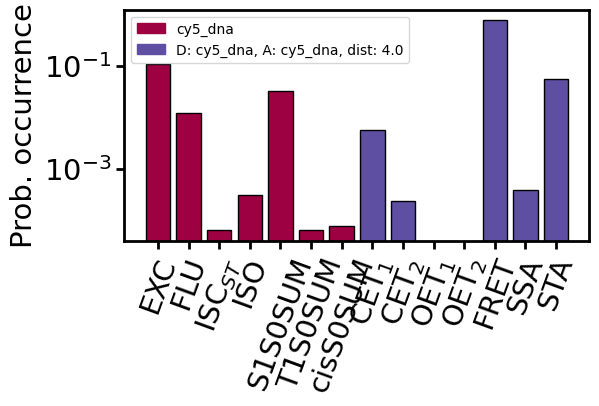

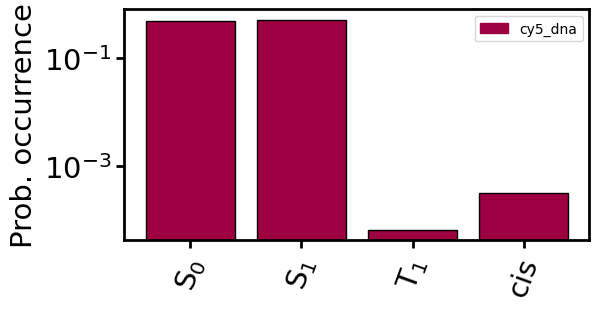

In [10]:
prediction.plot_frequency_transitions(scale=1)
prediction.plot_frequency_states(scale=1)

## Run a simulation

In [11]:
simulation = si.Simulation(transition_set)
simulation

In [12]:
%%time
# simulate until it reaches given end_time
simulation.run(start_at=None, size=1e6, end_time=0.1, seed=rng, use_memmap=None)
mi.print_class(simulation)

Floating point precision error warning:
 The smallest safe increment is 1.39e-17.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1, 1]
 gives a probability of 6.22e-07 for a smaller increment to be drawn.


Attributes of <fluopy.simulation.Simulation object at 0x000001A00830B8C0>:
.................................................................
transition_set = <fluopy.transitions.TransitionSet object at 0x000001A0083097F0>
_________________________________________________________________
time_series = array([0.00000000e+00, 5.75837004e-08, 5.7745339....99998755e-02, 1.00000000e-01], shape=(6051527,))
_________________________________________________________________
transition_series = array([ 1, 61, 60, ..., 57,  7, 57], shape=(6051525,), dtype=uint32)
_________________________________________________________________
state_series = array([[0, 1, 0, ..., 6, 6, 6],
       [0, 0, 1, ..., 0, 1, 0]], shape=(2, 6051526), dtype=int8)
_________________________________________________________________
memmap_path = None
_________________________________________________________________


CPU times: total: 21.5 s
Wall time: 21.7 s


## Analyze the simulation

In [13]:
analysis = an.Analysis(simulation=simulation)
mi.print_class(analysis)

Attributes of <fluopy.analysis.Analysis object at 0x000001A00830B620>:
.................................................................
simulation = <fluopy.simulation.Simulation object at 0x000001A00830B8C0>
_________________________________________________________________
frequency_transitions = array([1.08464891e-01, 1.23426740e-02, 6.0811117...8601e-01,
       3.95768009e-04, 5.60673549e-02])
_________________________________________________________________
frequency_states = {'cy5_dna': array([4.99893429e-01, 4.99893336e-01, 3.41028657e-05, 1.79132716e-04])}
_________________________________________________________________
transition_time_distributions = [array([5.75837004e-08, 2.43814055e-08, 3.7604061...6.61793222e-08, 4.83034908e-08], shape=(656378,)), array([1.08028480e-10, 1.36729061e-12, 1.7263118... 1.26793367e-10, 2.92761926e-11], shape=(74692,)), array([1.85347066e-12, 8.06076628e-11, 1.9416100... 1.92588584e-11, 3.25191402e-11, 5.52729390e-11]), array([9.10271807e-11, 1

array([[<Axes: title={'center': '$\\tau$ of cy5_dna\n            EXC'}, xlabel='time to transition [s]', ylabel='PD'>]],
      dtype=object)

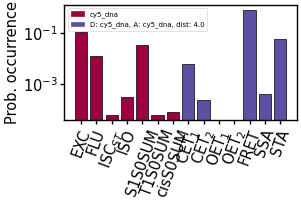

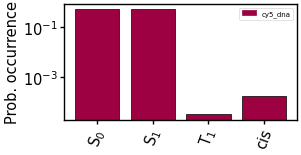

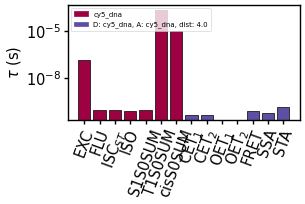

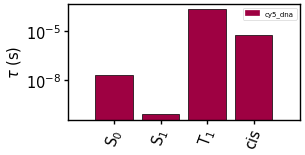

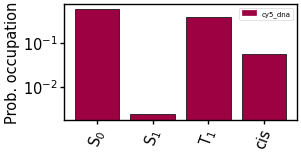

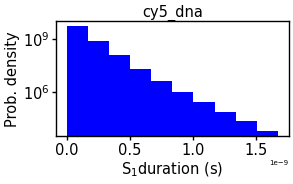

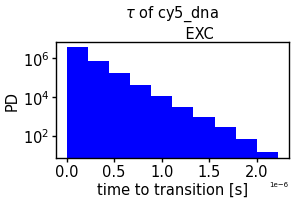

In [14]:
analysis.get_fluorescence_lifetimes(fluorophore="cy5_dna")
analysis.get_emitting_transition_lifetimes(fluorophore="cy5_dna")

analysis.plot_frequency_transitions(scale=0.5)
analysis.plot_frequency_states(scale=0.5)
analysis.plot_mean_transition_times(scale=0.5)
analysis.plot_mean_lifetimes(scale=0.5)
analysis.plot_state_occupations(scale=0.5)
analysis.plot_lifetime_distributions(scale=0.5, fluorophore="cy5_dna", state_identity=1)
analysis.plot_transition_time_distributions(
    scale=0.5, fluorophore="cy5_dna", transition_id=0
)

## Simulation of experimentally observable (photons per frames) only

#### Extract photon emission events from simulation

In [15]:
%%time
emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(600, 800))
emissions.extract(simulation=simulation)
emissions

CPU times: total: 46.9 ms
Wall time: 64.3 ms


#### Simulate photon emission events

Correct for detection efficiency and noise contributions:

In [16]:
emissions.add_photon_collection_objective(p=0.1, seed=rng)  # 1.
emissions.add_quantum_efficiency(p=0.9, seed=rng)  # 3.1.
emissions.add_poisson_noise(
    rate=0.05, seed=rng
)  # 3.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10, seed=rng)  # 4.
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 5. (readout noise)
emissions

emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(660, 700))
emissions.extract(simulation=approximation)  

In [17]:
# 2.
# at this point, the bandpass filter was applied
# yet, the effect of photon collection by the objective is missing
# the order is not relevant for two consecutive binomial distributions
# it is more convenient to apply the bandpass first because it needs the
# information about the emitting fluorophore whereas all the other effects are
# roughly wavelength independent
p_photon_collection = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emissions.add_photon_collection_objective(p=p_photon_collection)  # 1.
emissions.add_quantum_efficiency(p=0.9)  # 4.1.
emissions.add_transmittance(p=0.99)  # 3 (depending on number of components of optical
# path, may be applied multiple times)
emissions.add_poisson_noise(rate=0.05)  # 4.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10)  # 5. (+ multiplicative noise)
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 6. (readout noise)
# CIC (spurious noise) neglected since low probability to happen in the pixels of
# interest
emissions.apply_threshold(threshold=100)  # 7 (thresholding)

array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

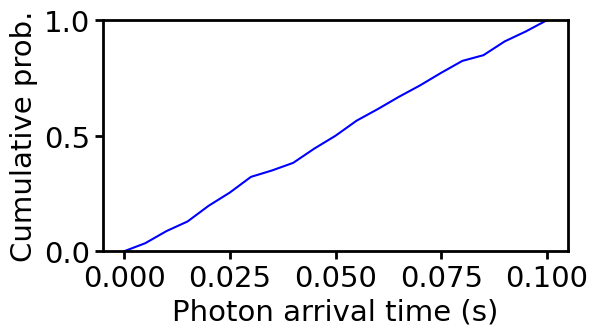

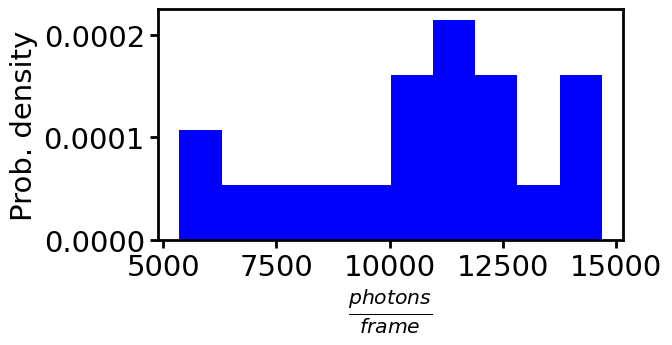

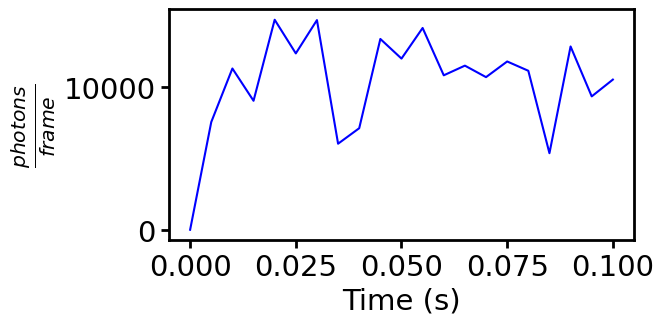

In [18]:
emissions.plot_cumulative_events(scale=1)
emissions.plot_histogram(scale=1)
emissions.plot_time_series(scale=1)

# to save the time_series and time_points
# emissions.save(path='', name_extension='test')

# to load time_series and time_points
# emissions.load(path='', name_extension='test')

## Simulation of pulsed excitation

In [19]:
%%time
emissions_tcspc = em.Emissions(frame_time="5ms", seed=rng, bandpass=None)
lifetimes_DA, lifetimes_D, lifetimes_all = emissions_tcspc.tcspc(
    transition_set=transition_set,
    number_pulses=5e5,
    pulse_duration=1e-11,
    time_between_pulses=1e-7,
    excitation_rates={"cy5_dna": 1e11},
    size=1e5,
    store_time_points=True,
    # details = True
)

the last frame (of index 0.05) has 1.00e+00 times the pulses of other frames.


CPU times: total: 1min 31s
Wall time: 1min 32s


array([[<Axes: xlabel='Lifetime (s)', ylabel='PD'>]], dtype=object)

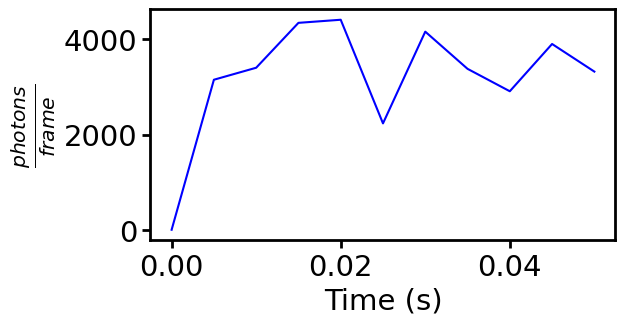

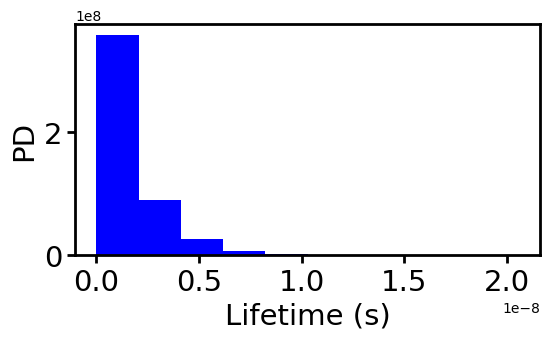

In [20]:
emissions_tcspc.plot_time_series()
fi.universal_figure(
    type_="hist", data=lifetimes_all, ylabel="PD", density=True, xlabel="Lifetime (s)"
)

## Fluorescence correlation spectroscopy

Observed fluorescence emission events can be analyzed by a correlation analysis.

In [21]:
fcs = fcs_p.FCS(emissions)
list(vars(fcs).keys())

['emissions', 'autocorrelation', 'tau']

### Autocorrelation of time points

In [22]:
%%time
fcs.autocorrelate_time_points(
    exp_min=-20, exp_max=-6, points_per_base=4, base=4, normalize=True
)

CPU times: total: 4.44 s
Wall time: 5.01 s


Attributes of <fluopy.fcs.FCS object at 0x000001A00830A900>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x000001A008309A90>
_________________________________________________________________
autocorrelation = array([0.        , 0.        , 0.        , 0.   ...9747, 1.24877656, 1.12061839,
       1.05790237])
_________________________________________________________________
tau = array([1.09785722e-12, 1.55260457e-12, 2.1957144... 1.04193529e-04, 1.47351902e-04, 2.08387058e-04])
_________________________________________________________________




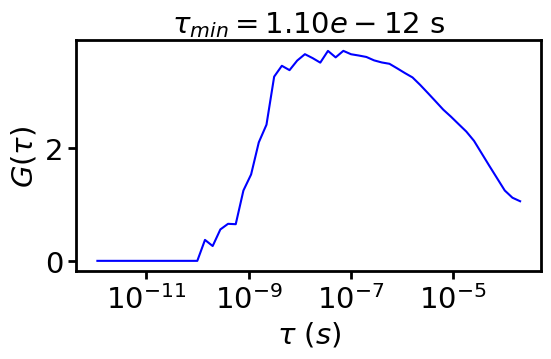

In [23]:
mi.print_class(fcs)
fcs.plot(normalize_to=None, unit="s", scale=1);

### Autocorrelation of time series

In [24]:
fcs.autocorrelate_time_series(log=True, m=4, normalize=True)

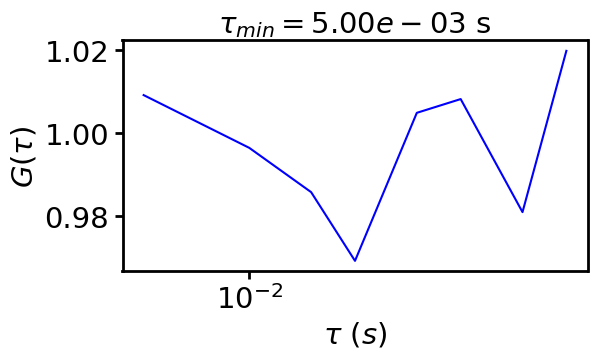

In [25]:
fcs.plot(normalize_to=None, unit="s", scale=1);

In [26]:
# some fcs fits are available:
# fcs_predict = fcs_p.fit_dark(tau, dark_lifetime, dark_occupation)
# fcs_predict = fcs_p.fit_antibunching(tau, excitation_rate, s1_lifetime)
# fcs_predict = fcs_p.fit_triplet_cis(tau, k_isc, k_T, k_01, k_10, k_iso, k_biso_eff)

## Antibunching

Alternatively, you can focus on fast time scales in a linear scale and observe antibunching.

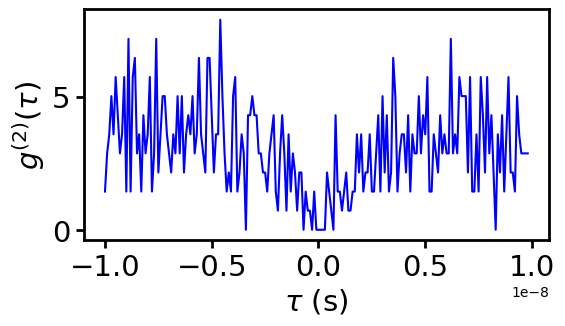

In [27]:
# sensible to tau_max and bin_width, see coincidence notebook
hist, bins = fcs_p.coincidence(
    emissions.event_time_points[: int(2e5)], tau_max=1e-8, bin_width=1e-10, seed=rng
)
fi.universal_figure(
    type_="line",
    data=[bins[:-2], hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    scale=1,
);